# « Développez une preuve de concept »

Projet n&#8239;$^\text{o}$ 7 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 18/05/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook d’entraînement du modèle *baseline* `EfficientNetB0` à 3 classes

Le dataset : http://vision.stanford.edu/aditya86/ImageNetDogs/

## Imports et constantes

In [1]:
DEFAULT_TRGT_IMG_SIZE = (224, 224)
DEFAULT_BATCH_SIZE = 8

import os
# Déclarer le backend avant d'importer keras (sinon par défaut c'est 'tensorflow'):
os.environ["KERAS_BACKEND"] = "torch"
# Memory optimization: Enable expandable segments to reduce fragmentation:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# Limiter la verbosité des logs de tensorflow:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from functions_model_building import (
    build_model_from_pretrained,
    MyF1Metric,
    MyKerasSequence,
    plot_accuracy_and_loss_values,
    plot_confusion_matrix,
)
import torch
import keras
# Memory optimization: Use mixed precision (if GPU supports it):
keras.mixed_precision.set_global_policy('mixed_float16')

from keras.applications.efficientnet import EfficientNetB0
from keras.applications.efficientnet_v2 import EfficientNetV2B0
from keras.applications.vgg16 import VGG16
from keras.metrics import SparseTopKCategoricalAccuracy

from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datetime as dt
import joblib
import itertools as it
import pytz

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

LOGGER_FORMAT = '%(asctime)s [%(levelname)s] %(message)s'
logging.Formatter.converter = lambda *_: dt.datetime.now(pytz.timezone('Europe/Paris')).timetuple()
logging.basicConfig(level=logging.INFO, format=LOGGER_FORMAT, force=True)
logr = logging.getLogger(__name__)
logr.setLevel(logging.DEBUG)

## Split train - val - test

In [2]:
input_img_paths = tuple([
    Path('images/n02090379-redbone'), Path('images/n02085936-Maltese_dog'), Path('images/n02088094-Afghan_hound')
])
logr.info(f"Les classes retenues : {input_img_paths}")
input_img_paths = tuple(path.glob('*.jpg') for path in input_img_paths)
input_img_paths = tuple(it.chain.from_iterable(input_img_paths))
logr.info(f"Résultat : un tuple de {len(input_img_paths)} images pour les 3 classes de races.")
breed_labels = tuple(str(path).split('/')[1] for path in input_img_paths)
breed_labels_encoded = LabelEncoder().fit_transform(breed_labels)
breed_labels_dict = dict(sorted(zip(breed_labels_encoded, breed_labels)))
logr.info(f"Distribution des classes : {dict(Counter(breed_labels))}")
display(dict(Counter(breed_labels)))
train_frac = 0.8
input_paths_train, input_paths_val_test, labels_train, labels_val_test = train_test_split(
    input_img_paths, breed_labels, train_size=train_frac,
    random_state=42, shuffle=True, stratify=breed_labels,
)
val_test_frac = 0.5
input_paths_val, input_paths_test, labels_val, labels_test = train_test_split(
    input_paths_val_test, labels_val_test, train_size=val_test_frac,
    random_state=42, shuffle=True, stratify=labels_val_test
)
del input_paths_val_test, labels_val_test
logr.info(f"Train size ({train_frac}): {len(input_paths_train)}")
logr.info(f"Val size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_val)}")
logr.info(f"Test size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_test)}")

2026-06-11 02:14:30,139 [INFO] Les classes retenues : (PosixPath('images/n02090379-redbone'), PosixPath('images/n02085936-Maltese_dog'), PosixPath('images/n02088094-Afghan_hound'))
2026-06-11 02:14:30,159 [INFO] Résultat : un tuple de 639 images pour les 3 classes de races.
2026-06-11 02:14:30,162 [INFO] Distribution des classes : {'n02090379-redbone': 148, 'n02085936-Maltese_dog': 252, 'n02088094-Afghan_hound': 239}


{'n02090379-redbone': 148,
 'n02085936-Maltese_dog': 252,
 'n02088094-Afghan_hound': 239}

2026-06-11 02:14:30,170 [INFO] Train size (0.8): 511
2026-06-11 02:14:30,170 [INFO] Val size (0.1): 64
2026-06-11 02:14:30,171 [INFO] Test size (0.1): 64


## Entraînement

Déclarer les paramètres :

In [3]:
PRTR_MDL = EfficientNetB0
PREPROCESSING_FUNC = keras.applications.efficientnet.preprocess_input
train_seq = MyKerasSequence(input_paths_train, labels_train, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
val_seq = MyKerasSequence(input_paths_val, labels_val, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
test_seq = MyKerasSequence(input_paths_test, labels_test, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
N_CLASSES = 3
TOP_K_CATEG_ACC = 2
N_EPOCHS = 40
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN__from={PRTR_MDL.__name__}__n_cls={N_CLASSES}__n_eps={N_EPOCHS}__drpt={DROPOUT_RATE:.2f}__LR={LR}'

Construire le modèle :

In [ ]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    layers_to_finetune='block7',
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        SparseTopKCategoricalAccuracy(TOP_K_CATEG_ACC),
        MyF1Metric(average='macro', name='f1_macro')
    ],
)
display(
    # model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Entraînement et validation :

In [5]:
torch.cuda.empty_cache()

2026-06-11 02:14:31,413 [INFO] Entraînement du modèle 'CNN__from=EfficientNetB0__n_cls=3__n_eps=40__drpt=0.20__LR=1e-05'...
W0000 00:00:1781136873.289964 3017803 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-06-11 02:22:59,048 [INFO] Entraînement du modèle 'CNN__from=EfficientNetB0__n_cls=3__n_eps=40__drpt=0.20__LR=1e-05' terminé
2026-06-11 02:22:59,048 [INFO] Sauvegarder l'objet 'models/CNN__from=EfficientNetB0__n_cls=3__n_eps=40__drpt=0.20__LR=1e-05_model.keras'
2026-06-11 02:22:59,636 [INFO] Sauvegarder l'objet 'models/CNN__from=EfficientNetB0__n_cls=3__n_eps=40__drpt=0.20__LR=1e-05_history.joblib'


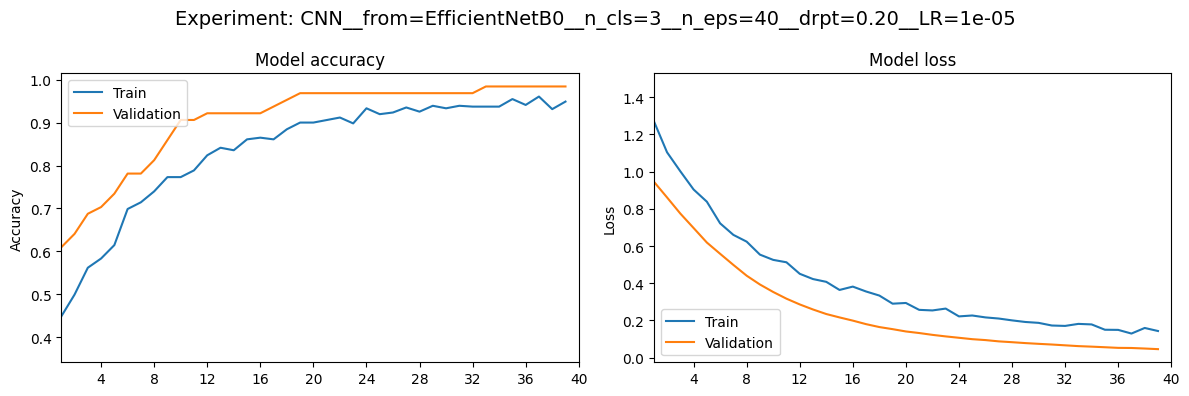

2026-06-11 02:23:00,642 [INFO] Précision finale de l'entraînement: 0.9491
2026-06-11 02:23:00,644 [INFO] Précision finale de la validation: 0.9844
2026-06-11 02:23:00,644 [INFO] Loss finale de l'entraînement: 0.1431
2026-06-11 02:23:00,645 [INFO] Loss finale de la validation: 0.0456


In [6]:
path_to_model = f'models/{experiment_name}_model.keras'
path_to_history = f'models/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'upper left', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

2026-06-11 02:23:00,654 [INFO] Évaluation sur les données de test :


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 1.0000 - f1_macro: 1.0000 - loss: 0.0274 - sparse_top_k_categorical_accuracy: 1.0000


2026-06-11 02:23:02,388 [INFO] loss, accuracy = [0.02738223597407341, 1.0, 1.0, 1.0]


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step


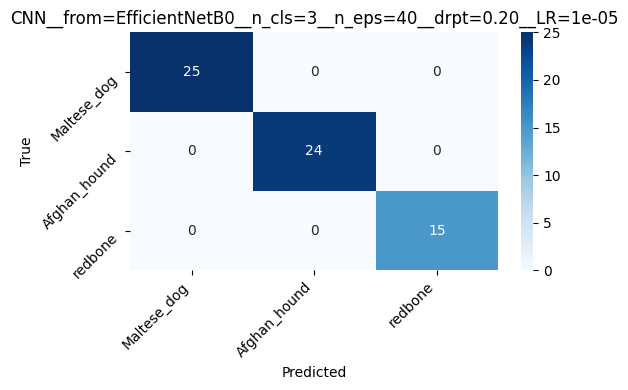

In [7]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.yset, breed_labels_dict.values(), title=f'{experiment_name}')